# BAL Data Clustering and initial analysis

In this notebook we will:
- cluster data w.r.t. to the neutrophil count,
- cluster the rest of cell types using `KMeans`,
- perform initial analysis of the data.

Let us start from imports and defining paths:

In [ ]:
import sys
sys.path.insert(0, '../lib')

In [ ]:
import collections
from collections import defaultdict
from collections import namedtuple
import os
import itertools

from sklearn import cluster as sk_cluster
from sklearn import manifold as sk_manifold
from sklearn import metrics as sk_metrics
from sklearn import preprocessing as sk_preprocessing
import matplotlib.pyplot as plt
import numpy as np
import pandas
import seaborn as sns

import common_data

In [ ]:
EHR_LABALES_PATH = common_data.CLINICAL_LABELS
FLOW_DATA_PATH = common_data.DATA / '2023-10-13-nn_lympho_flow.csv'
RESULT_DF_PATH = common_data.SC_CLUSTERS


BAL_BARCODE_COLNAME = 'bal_barcode'
NEUTROPHIL_COLNAME = 'LYMPHO_NNORMED:Neutrophils percent'
NEUTROPHIL_NORMALIZED_POSTFIX = '_NN'
NON_NEUTROPHIL_COLNAMES = [
    'LYMPHO_NNORMED:B cells',
    'LYMPHO_NNORMED:CD4 T cells',
    'LYMPHO_NNORMED:CD8 T cells',
    'LYMPHO_NNORMED:Classical monocytes-1 CCR2',
    'LYMPHO_NNORMED:Classical monocytes-2 IL1B',
    'LYMPHO_NNORMED:DC1',
    'LYMPHO_NNORMED:DC2',
    #'LYMPHO_NNORMED:Hematopoietic stem cells',
    'LYMPHO_NNORMED:MRC1+C1QA+',
    'LYMPHO_NNORMED:MRC1+C1QA-',
    'LYMPHO_NNORMED:Migratory DC',
    'LYMPHO_NNORMED:NUPR1+ Macs',
    'LYMPHO_NNORMED:Non-classical monocytes',
    'LYMPHO_NNORMED:Perivascular macrophages',
    'LYMPHO_NNORMED:Plasma cells',
    'LYMPHO_NNORMED:Proliferating CD4 T cells',
    'LYMPHO_NNORMED:Proliferating CD8 T cells',
    'LYMPHO_NNORMED:Proliferating NUPR1+ Macs',
    'LYMPHO_NNORMED:Proliferating gdT cells',
    'LYMPHO_NNORMED:Proliferating plasma cells',
    'LYMPHO_NNORMED:Tregs',
    'LYMPHO_NNORMED:gdT cells',
    'LYMPHO_NNORMED:pDC',
]

NEUTROPHIL_NORMALIZED_COLNAMES = [
    cn + NEUTROPHIL_NORMALIZED_POSTFIX
    for cn in NON_NEUTROPHIL_COLNAMES
]


RANDOM_SEED = 42 # Be careful with chaning the seed as some parts of the post-hoc analysis depend on it.


NEUTROPHIL_CLUSTERS_NB = 2
NEUTROPHIL_CLUSTERING_COL_NAME = 'Neutrophil Cluster'


KMEANS_N_INIT = 10
MIN_NB_OF_CLUSTERS_CANDIDATE = 5
MAX_NB_OF_CLUSTERS_CANDIDATE = 20
NB_OF_TRIES_PER_CANDIDATE = 10
PERCENTAGE_PERTURBATION_STD = 0.00005
CLUSTERING_SORTING_COLUMN = 'LYMPHO_NNORMED:Perivascular macrophages_NN'


CLUSTERS_COLORMAP = 'PiYG'
FINAL_CLUSTERING_COLNAME = 'clusters_final'


NEUTROPHIL_COLOR = (0.0, 0.0, 1.0)

Now - let's load the data:

In [2]:
import pandas


ehr_labels = pandas.read_csv(EHR_LABALES_PATH)
flow_df = pandas.read_csv(FLOW_DATA_PATH)

, and merge it with the ground truth labels:

In [3]:
flow_df_with_gt = pandas.merge(flow_df, ehr_labels, left_on='individual', right_on=BAL_BARCODE_COLNAME)

## Neutrophil clustering

In [ ]:
neutrophil_kmeans_clusterer = sk_cluster.KMeans(
    n_clusters=NEUTROPHIL_CLUSTERS_NB,
    n_init=KMEANS_N_INIT,
    random_state=RANDOM_SEED,
)


neutrophil_clusters = neutrophil_kmeans_clusterer.fit_predict(flow_df_with_gt[[NEUTROPHIL_COLNAME]])

Now - let's order clusters w.r.t. to the mean neutrophil_percentages:

In [5]:
n_percentages = np.array(
    [
        flow_df_with_gt[NEUTROPHIL_COLNAME].loc[neutrophil_clusters == cluster_ind_].mean()
        for cluster_ind_ in range(NEUTROPHIL_CLUSTERS_NB)
    ]
)


n_percentages_argsort = n_percentages.argsort()
neutrophil_sorted_clusters = np.array([n_percentages_argsort[nc] for nc in neutrophil_clusters])

and visualize neutrophil clusters distribution:

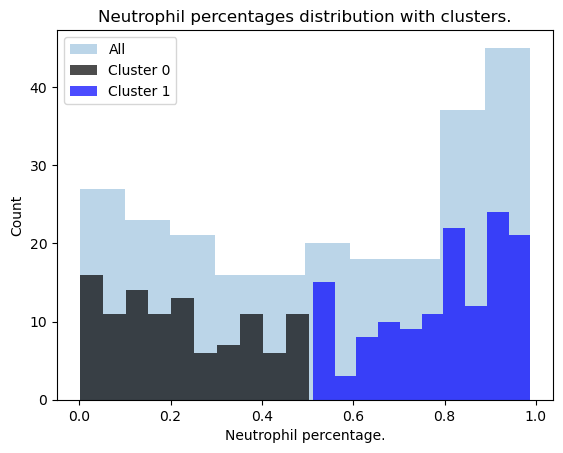

In [ ]:
plt.hist(flow_df_with_gt[NEUTROPHIL_COLNAME], alpha=0.3, label='All', color=None)
for cluster_ in range(NEUTROPHIL_CLUSTERS_NB):
    color = None
    if cluster_ == 0:
        color = 'black'
    if cluster_ == NEUTROPHIL_CLUSTERS_NB - 1:
        color = 'blue'
    plt.hist(
        flow_df_with_gt[NEUTROPHIL_COLNAME].loc[neutrophil_sorted_clusters == cluster_],
        alpha=0.7,
        label=f'Cluster {cluster_}',
        color=color
    )
plt.legend()
plt.title('Neutrophil percentages distribution with clusters.')
plt.xlabel('Neutrophil percentage.')
plt.ylabel('Count')
None

Now - let's prepare neutrophil colors for further analyses:

In [7]:
neutrophil_colors = [
    np.array(NEUTROPHIL_COLOR) * nc_ / (NEUTROPHIL_CLUSTERS_NB - 1)
    for nc_ in neutrophil_clusters
]

Now - when we have neutrophils clustered - let us prepare a neutrophil normalized data:

In [8]:
flow_df_with_gt[NON_NEUTROPHIL_COLNAMES].sum(axis=1) + flow_df_with_gt[NEUTROPHIL_COLNAME]

0      0.997559
1      1.000000
2      1.000000
3      0.999788
4      1.000000
         ...   
236    0.999980
237    0.999941
238    1.000000
239    0.999948
240    1.000000
Length: 241, dtype: float64

In [9]:
flow_df_with_gt_with_nn = flow_df_with_gt.copy()

flow_df_with_gt_with_nn[NEUTROPHIL_NORMALIZED_COLNAMES] = flow_df_with_gt[NON_NEUTROPHIL_COLNAMES] / flow_df_with_gt[NON_NEUTROPHIL_COLNAMES].sum(axis=1).values.reshape((-1, 1))# * (1 - )
flow_df_with_gt_with_nn[NEUTROPHIL_NORMALIZED_COLNAMES] = flow_df_with_gt_with_nn[NEUTROPHIL_NORMALIZED_COLNAMES] * (1 - flow_df_with_gt_with_nn[NEUTROPHIL_COLNAME]).values.reshape((-1, 1))

## Clustering of Neutrophil Normalized data:

The following code finds out number of clusters using algorithm for cluster nb determination from the CellCharter paper.

First - let us compute clusterings required for the evaluation of the proposed number of clusters (integers from the `[MIN_NB_OF_CLUSTERS_CANDIDATE, MAX_NB_OF_CLUSTERS_CANDIDATE]` interval):

In [ ]:
from collections import defaultdict
from collections import namedtuple
import os

from sklearn import cluster as sk_cluster
from sklearn import metrics as sk_metrics
import numpy as np
import matplotlib.pyplot as plt


CLUSTERING_FMS_FIG_FILENAME = 'fmses.png'
CLUSTERING_KMEANS_CLUSTERER_NAME_PREFIX = 'kmeans'
CLUSTERING_KMEANS_PREDICTIONS_NAME_PREFIX = 'kmeans_predictions'
CLUSTERING_KMEANS_PREDICTIONS_SUBDIR = 'kmeans_predictions'
CLUSTERING_KMEANS_SUBDIR = 'kmeans_clusterers'
CLUSTERING_SAVING_SUBDIR = 'clustering'


def get_best_clusterings_from_cluster_nb_to_fmses(cluster_nb_to_fmses):
    cluster_nb_to_mean = {cn: np.mean(cluster_nb_to_fmses[cn]) for cn in cluster_nb_to_fmses}
    means = [cluster_nb_to_mean[cn] for cn in cluster_nb_to_fmses]
    clusters = list(cluster_nb_to_fmses.keys())
    best_clusters, best_clusters_fmses = [], []
    for cluster_ind in range(1, len(clusters) - 1):
        if means[cluster_ind] > max(means[cluster_ind - 1], means[cluster_ind + 1]):
            best_clusters.append(clusters[cluster_ind])
            best_clusters_fmses.append(means[cluster_ind])
    return best_clusters, best_clusters_fmses


def plot_cluster_size_to_fmses(
    cluster_nb_to_fmses,
    fms_clusters,
    fmses,
    best_clusters,
    best_clusters_fmses,
    save_fig: bool = True,
    path: str = None,
):
    cluster_nb_to_mean = {cn: np.mean(cluster_nb_to_fmses[cn]) for cn in cluster_nb_to_fmses}
    plt.scatter(fms_clusters, fmses, alpha=0.05, label='FMS')
    plt.scatter(cluster_nb_to_mean.keys(), cluster_nb_to_mean.values(), label='mean FMS', alpha=0.8)
    plt.scatter(best_clusters, best_clusters_fmses, label='Best Clusters')
    plt.legend()
    if save_fig:
        fig_path = os.path.join(path, CLUSTERING_FMS_FIG_FILENAME)
        plt.savefig(fig_path)


CCSResult = namedtuple(
    typename='CCSResult',
    field_names=[
        'cluster_nb_to_k_means',
        'cluster_nb_to_predictions',
        'fms_clusters',
        'fmses',
        'cluster_nb_to_fmses',
        'best_clusterings',
        'best_clusterings_fmses'
    ]
)


def main_cluster_selection(
    clusters_to_analyze,
    nb_of_tries_per_cluster_nb,
    take_every_example_for_training,
    predictions,
    first_random_state=42,
):
    cluster_nb_to_k_means = defaultdict(list)

    current_seed_offset = 0
    for nb_of_clusters in clusters_to_analyze:
        print(nb_of_clusters)
        for _ in range(nb_of_tries_per_cluster_nb):
            current_k_means = sk_cluster.MiniBatchKMeans(
                n_clusters=nb_of_clusters,
                n_init='auto',
                random_state=first_random_state + current_seed_offset,
            )
            current_seed_offset += 1
            cluster_nb_to_k_means[nb_of_clusters].append(current_k_means.fit(predictions[::take_every_example_for_training]))

    cluster_nb_to_predictions = defaultdict(list)

    for nb_of_clusters, k_means_clusterers in cluster_nb_to_k_means.items():
        for k_means_clusterer in k_means_clusterers:
            cluster_nb_to_predictions[nb_of_clusters].append(
                 k_means_clusterer.predict(predictions))

    fms_clusters, fmses, cluster_nb_to_fmses = [], [], defaultdict(list)

    for current_cluster_ind in range(1, len(clusters_to_analyze) - 1):
        current_cluster = clusters_to_analyze[current_cluster_ind]
        previous_cluster = clusters_to_analyze[current_cluster_ind - 1]
        next_cluster = clusters_to_analyze[current_cluster_ind + 1]
        for current_clusters_predictions in cluster_nb_to_predictions[current_cluster]:
            for previous_clusters_predictions in cluster_nb_to_predictions[previous_cluster]:
                fms_clusters.append(current_cluster)
                current_fms = sk_metrics.fowlkes_mallows_score(current_clusters_predictions, previous_clusters_predictions)
                fmses.append(current_fms)
                cluster_nb_to_fmses[current_cluster].append(current_fms)
            for next_clusters_predictions in cluster_nb_to_predictions[next_cluster]:
                fms_clusters.append(current_cluster)
                current_fms = sk_metrics.fowlkes_mallows_score(current_clusters_predictions, next_clusters_predictions)
                fmses.append(current_fms)
                cluster_nb_to_fmses[current_cluster].append(current_fms)

    best_clusterings, best_clusterings_fmses = get_best_clusterings_from_cluster_nb_to_fmses(cluster_nb_to_fmses=cluster_nb_to_fmses)
    return CCSResult(
        cluster_nb_to_k_means,
        cluster_nb_to_predictions,
        fms_clusters,
        fmses,
        cluster_nb_to_fmses,
        best_clusterings,
        best_clusterings_fmses,
    )


def get_best_clusters_from_cs_result(cs_result):
    best_clusters = cs_result[-2]
    best_clusterers = {}
    for bc in best_clusters:
        inertias = np.array([km.inertia_ for km in cs_result[0][bc]])
        best_cl_index = np.argmin(inertias)
        best_clusterers[bc] = cs_result[0][bc][best_cl_index]
    return best_clusterers

In [11]:
def perform_cluster_selection(
    vectors,
    clusters_to_select=None,
    nb_of_tries_per_cluster_nb=15,
    take_every_example_for_training=1,
    plot=True,
):
    if clusters_to_select is None:
        clusters_to_select = list(range(3, 30 + 1))
    pl_result = main_cluster_selection(
        clusters_to_analyze=clusters_to_select,
        nb_of_tries_per_cluster_nb=nb_of_tries_per_cluster_nb,
        take_every_example_for_training=take_every_example_for_training,
        predictions=vectors,
    )
    if plot:
        plot_cluster_size_to_fmses(
            cluster_nb_to_fmses=pl_result.cluster_nb_to_fmses,
            fms_clusters=pl_result.fms_clusters,
            fmses=pl_result.fmses,
            best_clusters=pl_result.best_clusterings,
            best_clusters_fmses=pl_result.best_clusterings_fmses,
            save_fig=False,
            path=None,
    )
    pl_best_clusterers = get_best_clusters_from_cs_result(pl_result)
    return pl_result, pl_best_clusterers

In [12]:
from sklearn import preprocessing as sk_preprocessing

scaler = sk_preprocessing.StandardScaler()
flow_data_nn = (flow_df_with_gt_with_nn[NEUTROPHIL_NORMALIZED_COLNAMES + [NEUTROPHIL_COLNAME]]).copy() ** 0.5
flow_data_nn[NEUTROPHIL_NORMALIZED_COLNAMES + [NEUTROPHIL_COLNAME]] = scaler.fit_transform(flow_data_nn)

In [13]:
flow_data_nn.shape

(241, 23)

#### Now - let us compute appropriate Fowlkes–Mallows indexes:

3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30


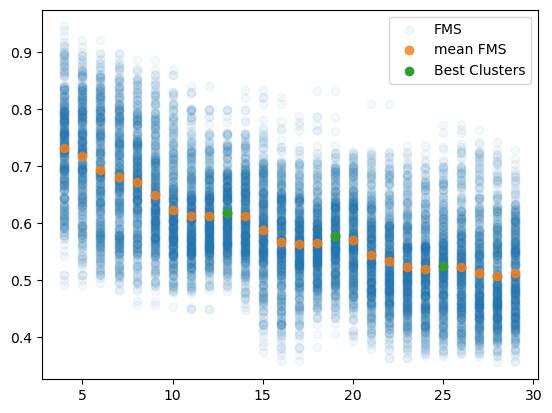

In [14]:
cs_result, cs_best_clusterers = perform_cluster_selection(
    vectors=flow_data_nn[NEUTROPHIL_NORMALIZED_COLNAMES + [NEUTROPHIL_COLNAME]],
)

Now - let us analyze the results:

Based on the analysis above we select `FINAL_NB_OF_CLUSTERS`:

In [17]:
FINAL_NB_OF_CLUSTERS = 13

and train and obtain final clustering:

In [18]:
final_kmeans_clusterer = cs_best_clusterers[FINAL_NB_OF_CLUSTERS]

final_k_means_predictions = final_kmeans_clusterer.predict(flow_data_nn[NEUTROPHIL_NORMALIZED_COLNAMES + [NEUTROPHIL_COLNAME]])

.. and sort it w.r.t. `CLUSTERING_SORTING_COLUMN`:

In [19]:
clustering_percentages = [
    flow_data_nn[CLUSTERING_SORTING_COLUMN].loc[final_k_means_predictions == cluster_nb].mean()
    for cluster_nb in range(FINAL_NB_OF_CLUSTERS)
]

clustering_sorting = np.array(clustering_percentages).argsort().argsort()
final_k_means_predictions_sorted = np.array([
    clustering_sorting[cl] for cl in final_k_means_predictions
])

.. and clustering related colors variables:

In [20]:
final_clusters_colormap = plt.cm.get_cmap(CLUSTERS_COLORMAP, FINAL_NB_OF_CLUSTERS)
final_k_means_predictions_colors = np.array(
    [final_clusters_colormap(ind_) for ind_ in final_k_means_predictions_sorted]
)
patient_cluster_neutrophil_perm = np.argsort(final_k_means_predictions_sorted + 0.5 * neutrophil_sorted_clusters)

In [21]:
celltype_cols = [
    ct_col[15:]
    for ct_col in NEUTROPHIL_NORMALIZED_COLNAMES + [NEUTROPHIL_COLNAME]
]

In [22]:
cta_cd_df = pandas.DataFrame(
    final_kmeans_clusterer.cluster_centers_[clustering_sorting.argsort()],
    columns=celltype_cols,
    #index=clustering_sorting,
)

In [ ]:
sc_cluster_name = [
    '0 - DC+',
    '1 - Neutr. + Mono2',
    '2 - gdT. + Mono(1&NC)',
    '3 - CD4/8/Treg',
    '4 - Nupr Macs',
    '5 - Mac-',
    '6 - Prol. Lymph',
    '7 - CD8+',
    '8 - Prol. Lymph\n& Plasma' ,
    '9 - MRC1 + Neutr. + Mono',
    '10 - Neutr-',
    '11 - Nupr + Peri\nMacs',
    '12 - Prol. + DC']

Text(0.5, 1.0, 'Average Cell Type abundance in cluster')

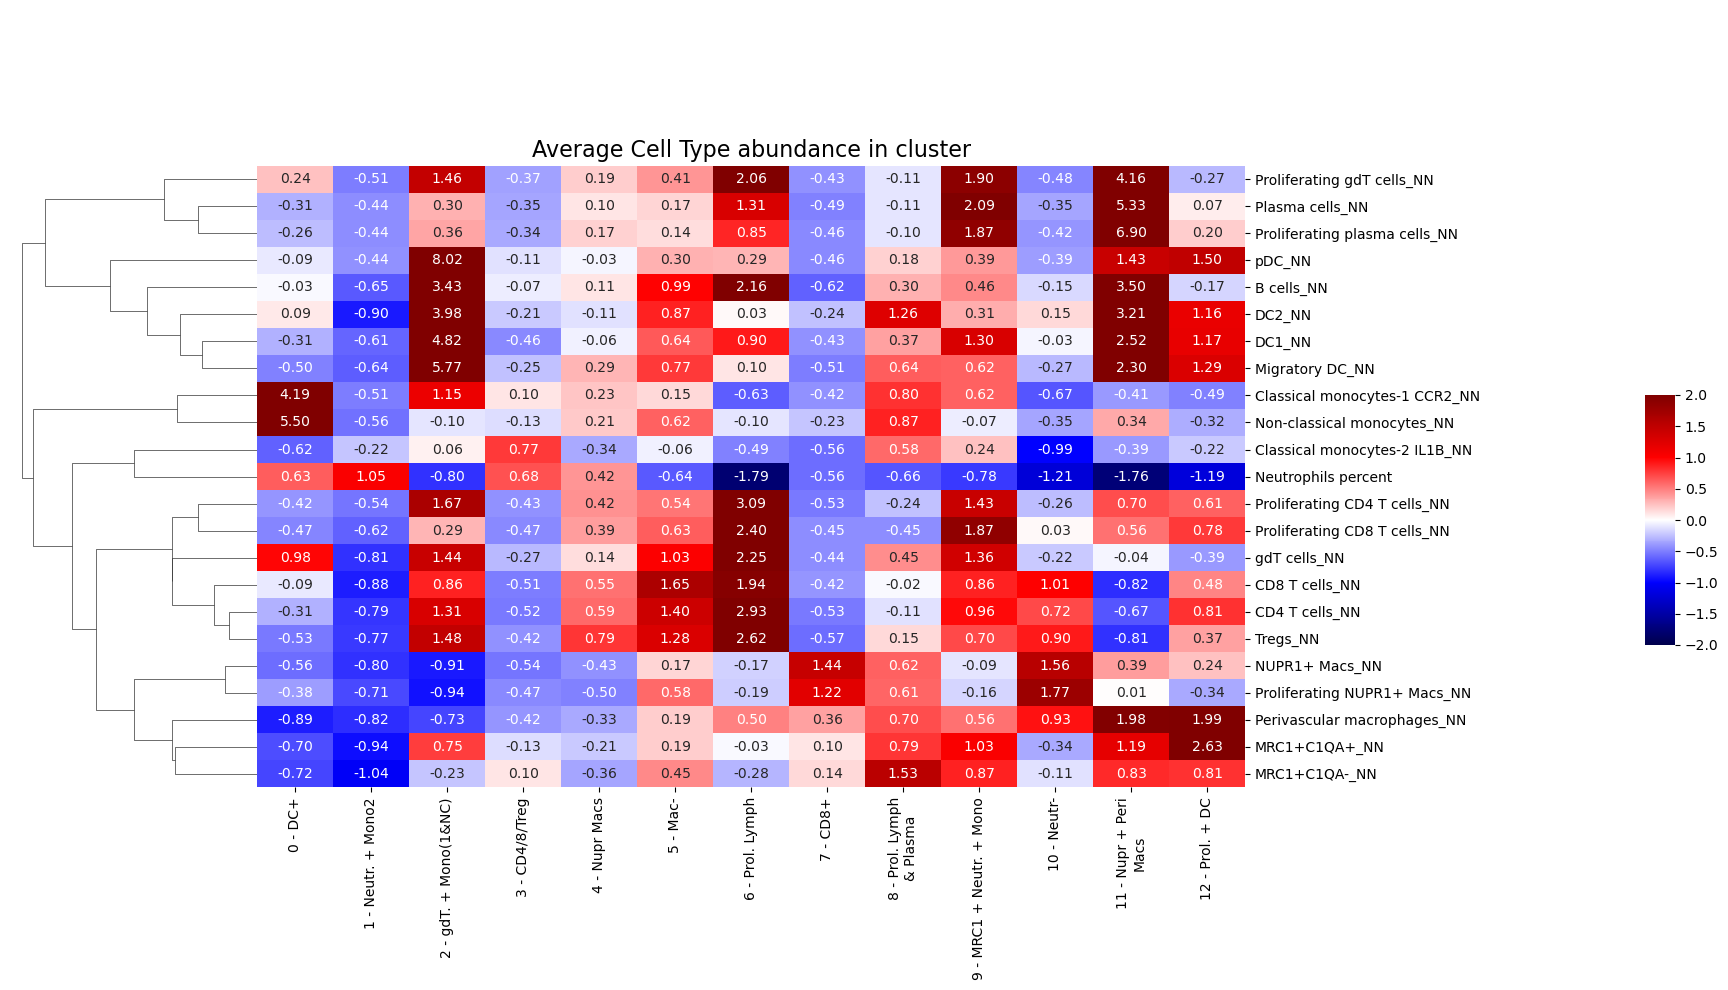

In [ ]:
celltype_clustermap = sns.clustermap(
    cta_cd_df.T,
    col_cluster=False,
    xticklabels=sc_cluster_name,
    center=0,
    vmin=-2,
    vmax=2,
    cmap='seismic',
    cbar_pos=(1.1, 0.35, 0.02, 0.25),
    annot=True,
    figsize=(15, 10),
    fmt='.2f'
)
celltype_clustermap.ax_heatmap.set_title('Average Cell Type abundance in cluster', fontsize=16)

In [25]:
percentages = pandas.concat(
    [
        flow_df_with_gt_with_nn[NEUTROPHIL_NORMALIZED_COLNAMES + [NEUTROPHIL_COLNAME]][final_k_means_predictions_sorted == i].mean().to_frame()
        for i in range(FINAL_NB_OF_CLUSTERS)
    ],
    axis=1
)

In [26]:
percentages_text = percentages.applymap(lambda x: f'{round(100 * x)}%')

Text(0.5, 1.0, 'Average Cell Type abundance in cluster')

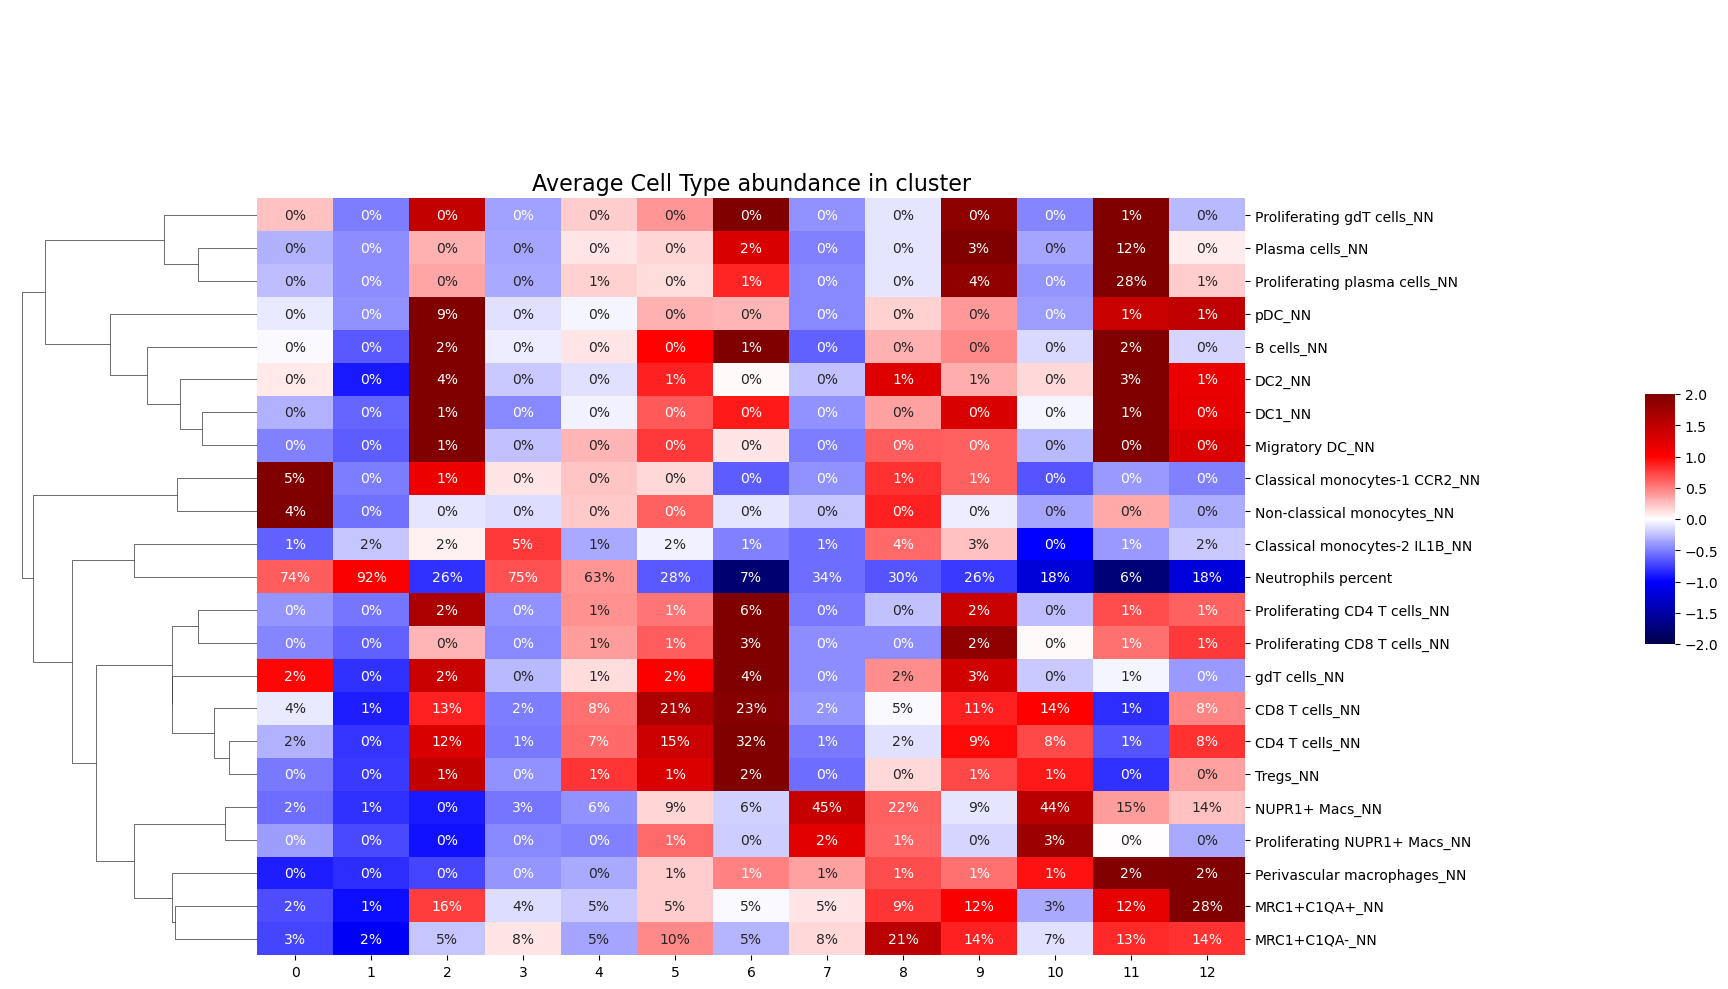

In [ ]:
celltype_clustermap = sns.clustermap(
    cta_cd_df.T,
    col_cluster=False,
    #xticklabels=sc_cluster_name,
    center=0,
    vmin=-2,
    vmax=2,
    cmap='seismic',
    cbar_pos=(1.1, 0.35, 0.02, 0.25),
    annot=percentages_text,
    figsize=(15, 10),
    fmt='',
)
celltype_clustermap.ax_heatmap.set_title('Average Cell Type abundance in cluster', fontsize=16)

In [40]:
percentages.sum(axis=0)

0    1.0
0    1.0
0    1.0
0    1.0
0    1.0
0    1.0
0    1.0
0    1.0
0    1.0
0    1.0
0    1.0
0    1.0
0    1.0
dtype: float64

In [ ]:
sc_cluster_name = [
    '0 - Neutrophil + Monocytes',
    '1 - Neutrophil dominated,
    '2 - gdT. + Mono(1&NC)',
    '3 - CD4/8/Treg',
    '4 - Nupr Macs',
    '5 - Mac-',
    '6 - Prol. Lymph',
    '7 - CD8+',
    '8 - Prol. Lymph\n& Plasma' ,
    '9 - MRC1 + Neutr. + Mono',
    '10 - Neutr-',
    '11 - Nupr + Peri\nMacs',
    '12 - Prol. + DC']

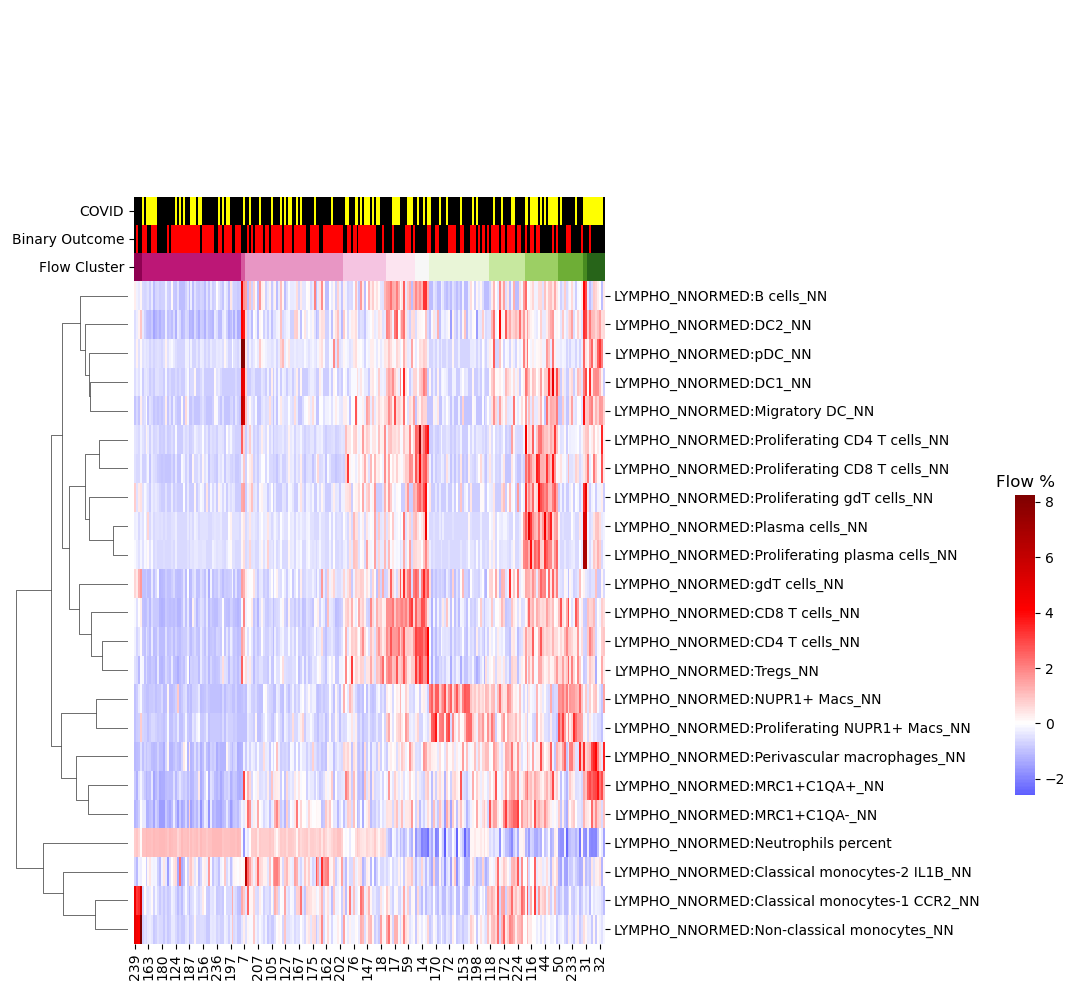

In [33]:
binary_outcome_colors = [
    (1.0, 0.0, 0.0) if bo else (0.0, 0.0, 0.0)
    for bo in flow_df_with_gt_with_nn['Binary_outcome']
]


vps = set(flow_df_with_gt_with_nn['viral_pathogen'])

is_vp_covid = {
    vp: isinstance(vp, str) and 'SARS-Cov-2' in vp
    for vp in vps
}

is_covid = flow_df_with_gt_with_nn['viral_pathogen'].apply(lambda x: is_vp_covid[x])

is_covid_colors = [
    (1.0, 1.0, 0.0) if isc else (0.0, 0.0, 0.0)
    for isc in is_covid
]


cmap = sns.clustermap(
    flow_data_nn.T[patient_cluster_neutrophil_perm],
    col_colors=[
        np.array(is_covid_colors)[patient_cluster_neutrophil_perm],
        np.array(binary_outcome_colors)[patient_cluster_neutrophil_perm],
        final_k_means_predictions_colors[patient_cluster_neutrophil_perm],
    ],
    col_cluster=False,
    method='complete',
    metric='cityblock',
    cbar_pos=(1.02, 0.2, 0.02, 0.3),
    center=0.0,
    cmap='seismic',
)

_ = cmap.ax_col_colors.set_yticks(
    ticks=[0.5, 1.5, 2.5],
    labels=['COVID', 'Binary Outcome', 'Flow Cluster'],
)

_ = cmap.ax_cbar.set_title('Flow %')

## Final Data saving

In [34]:
flow_df_with_gt_with_nn[FINAL_CLUSTERING_COLNAME] = final_k_means_predictions_sorted
flow_df_with_gt_with_nn[NEUTROPHIL_CLUSTERING_COL_NAME] = neutrophil_sorted_clusters

flow_df_with_gt_with_nn.to_csv(RESULT_DF_PATH)